# 07 — Event Predictions

Scrape a UFC event card, build features, predict with your chosen models.

**To use different models:** change the filenames in the config cell.
**Profile fallback:** fighters without model_data history get profile-only features. Tree models handle NaN natively.

## Config

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THESE to swap models                                ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  Options per slot:                                          ║
# ║    XGB:  xgb_baseline.json / xgb_tuned.json / xgb_prod.json║
# ║    LGB:  lgb_baseline.txt  / lgb_tuned.txt  / lgb_prod.txt ║
# ║    CAT:  cat_baseline.cbm  / cat_tuned.cbm  / cat_prod.cbm ║
# ╚══════════════════════════════════════════════════════════════╝
version = 'baseline'
XGB_FILE = f'xgb_{version}.json'
LGB_FILE = f'lgb_{version}.txt'
CAT_FILE = f'cat_{version}.cbm'

# Ensemble weights (set to equal, or load from best_params.json)
ENSEMBLE_WEIGHTS = {'XGBoost': 1/3, 'LightGBM': 1/3, 'CatBoost': 1/3}

# Set to None to auto-detect latest event, or paste a URL:
EVENT_URL = 'http://www.ufcstats.com/event-details/9a70f67ad2187fa3'
# EVENT_URL = 'http://www.ufcstats.com/event-details/abc123'

In [2]:
import pandas as pd
import numpy as np
import json, warnings, time, re
from pathlib import Path

import requests
from bs4 import BeautifulSoup
import lightgbm as lgb

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DATA = Path('./data') if Path('./data/model_data.csv').exists() else Path('../data')
MODEL_DIR = Path('../models') if not Path('./models').exists() else Path('./models')

df = pd.read_csv(DATA / 'model_data.csv', parse_dates=['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)

fighters_clean = pd.read_csv(DATA / 'fighters_clean.csv')
feature_cols = [line.strip() for line in open(DATA / 'feature_list.txt')]

print(f"Historical data: {len(df):,} fights through {df['event_date'].max().date()}")
print(f"Features: {len(feature_cols)}")
print(f"Fighters in DB: {len(fighters_clean):,}")

Historical data: 5,485 fights through 2026-04-11
Features: 310
Fighters in DB: 4,486


## Load Models

In [3]:
models = {}

xgb_path = MODEL_DIR / XGB_FILE
if xgb_path.exists():
    m = XGBClassifier()
    m.load_model(str(xgb_path))
    models['XGBoost'] = m
    print(f"✅ XGBoost:  {XGB_FILE}")
else:
    print(f"❌ XGBoost:  {xgb_path} not found")

lgb_path = MODEL_DIR / LGB_FILE
if lgb_path.exists():
    models['LightGBM'] = lgb.Booster(model_file=str(lgb_path))
    print(f"✅ LightGBM: {LGB_FILE}")
else:
    print(f"❌ LightGBM: {lgb_path} not found")

cat_path = MODEL_DIR / CAT_FILE
if cat_path.exists():
    m = CatBoostClassifier()
    m.load_model(str(cat_path))
    models['CatBoost'] = m
    print(f"✅ CatBoost: {CAT_FILE}")
else:
    print(f"❌ CatBoost: {cat_path} not found")

# Try loading saved ensemble weights
if ENSEMBLE_WEIGHTS == {'XGBoost': 1/3, 'LightGBM': 1/3, 'CatBoost': 1/3}:
    try:
        bp = json.load(open(DATA / 'best_params.json'))
        if 'best_ensemble_weights' in bp:
            ENSEMBLE_WEIGHTS = bp['best_ensemble_weights']
            print(f"\nLoaded ensemble weights: {ENSEMBLE_WEIGHTS}")
    except:
        pass

print(f"\nModels loaded: {list(models.keys())}")
print(f"Ensemble weights: { {k: f'{v:.3f}' for k, v in ENSEMBLE_WEIGHTS.items()} }")

✅ XGBoost:  xgb_baseline.json
✅ LightGBM: lgb_baseline.txt
✅ CatBoost: cat_baseline.cbm

Loaded ensemble weights: {'XGBoost': 0.3333, 'LightGBM': 0.3333, 'CatBoost': 0.3333}

Models loaded: ['XGBoost', 'LightGBM', 'CatBoost']
Ensemble weights: {'XGBoost': '0.333', 'LightGBM': '0.333', 'CatBoost': '0.333'}


## Scrape Event Card

In [4]:
HEADERS = {'User-Agent': 'Mozilla/5.0'}

def get_latest_event_url():
    resp = requests.get('http://www.ufcstats.com/statistics/events/completed?page=all', headers=HEADERS)
    soup = BeautifulSoup(resp.text, 'lxml')
    rows = soup.select('tr.b-statistics__table-row')
    for row in rows:
        link = row.select_one('a.b-link')
        if link and link['href'].strip():
            date_str = row.select('td')[-1].get_text(strip=True)
            return link['href'].strip(), link.get_text(strip=True), date_str
    return None, None, None

def scrape_event(event_url):
    resp = requests.get(event_url, headers=HEADERS)
    soup = BeautifulSoup(resp.text, 'lxml')
    name_tag = soup.select_one('h2.b-content__title span')
    event_name = name_tag.get_text(strip=True) if name_tag else 'Unknown Event'
    fights = []
    rows = soup.select('tr.b-fight-details__table-row')[1:]
    for row in rows:
        cols = row.select('td')
        if len(cols) < 2:
            continue
        fighters = row.select('a.b-link_style_black')
        if len(fighters) < 2:
            continue
        fight_url = row.get('data-link', '').strip()
        wc = cols[6].get_text(strip=True) if len(cols) > 6 else ''
        method = cols[7].get_text(strip=True) if len(cols) > 7 else ''
        fights.append({'fight_url': fight_url, 'weight_class': wc, 'method': method})
    return event_name, fights

def get_corners(fight_url):
    resp = requests.get(fight_url, headers=HEADERS)
    soup = BeautifulSoup(resp.text, 'lxml')
    fighters = soup.select('a.b-link.b-fight-details__person-link')
    statuses = soup.select('i.b-fight-details__person-status')
    if len(fighters) < 2:
        return None, None, None
    f1 = fighters[0].get_text(strip=True)
    f2 = fighters[1].get_text(strip=True)
    winner = None
    if len(statuses) >= 2:
        if statuses[0].get_text(strip=True) == 'W':
            winner = f1
        elif statuses[1].get_text(strip=True) == 'W':
            winner = f2
    return f1, f2, winner

# ── Get event ──
if EVENT_URL:
    url = EVENT_URL
    event_name = "Custom Event"
    event_date = ""
else:
    url, event_name, event_date = get_latest_event_url()

print(f"Event: {event_name}")
print(f"Date:  {event_date}")
print(f"URL:   {url}")

event_name_full, raw_fights = scrape_event(url)
if event_name_full != 'Unknown Event':
    event_name = event_name_full

print(f"\nScraping {len(raw_fights)} fight detail pages...")

card = []
for i, fight in enumerate(raw_fights):
    if fight['fight_url']:
        f1, f2, winner = get_corners(fight['fight_url'])
        time.sleep(0.3)
    else:
        f1, f2, winner = None, None, None
    if f1 and f2:
        card.append({
            'fighter_1': f1, 'fighter_2': f2,
            'weight_class': fight['weight_class'], 'winner': winner,
        })
        w_str = f" → {winner}" if winner else ""
        print(f"  {i+1:>2}. {f1:<25s} vs {f2:<25s} [{fight['weight_class']}]{w_str}")

has_results = any(f['winner'] for f in card)
print(f"\nCard: {len(card)} fights | Results available: {has_results}")

Event: Custom Event
Date:  
URL:   http://www.ufcstats.com/event-details/9a70f67ad2187fa3



Scraping 13 fight detail pages...
   1. Renato Moicano            vs Chris Duncan              [Lightweight] → Renato Moicano
   2. Virna Jandiroba           vs Tabatha Ricci             [Women's Strawweight] → Virna Jandiroba
   3. Abdul Rakhman Yakhyaev    vs Brendson Ribeiro          [Light Heavyweight] → Abdul Rakhman Yakhyaev
   4. Ethyn Ewing               vs Rafael Estevam            [Bantamweight] → Ethyn Ewing
   5. Tommy McMillen            vs Manolo Zecchini           [Featherweight] → Tommy McMillen
   6. Jose Delano               vs Robert Ruchala            [Featherweight] → Jose Delano
   7. Guilherme Pat             vs Thomas Petersen           [Heavyweight] → Thomas Petersen
   8. Alessandro Costa          vs Stewart Nicoll            [Flyweight] → Alessandro Costa
   9. Lando Vannata             vs Darrius Flowers           [Lightweight] → Darrius Flowers
  10. Alice Pereira             vs Hailey Cowan              [Women's Bantamweight] → Alice Pereira
  11. Azamat 

## Match Fighters & Build Features

Full history fighters get ~310 features.
Profile-only fallback fighters get ~15 features, rest NaN.

In [5]:
def find_fighter(name):
    for col in ['fighter_1', 'fighter_2']:
        mask = df[col].str.lower() == name.lower()
        if mask.any():
            return df.loc[mask, col].values[0]
    mask = fighters_clean['full_name'].str.lower() == name.lower()
    if mask.sum() == 1:
        return fighters_clean.loc[mask, 'full_name'].values[0]
    parts = name.lower().split()
    if len(parts) >= 2:
        mask = (fighters_clean['first_name'].str.lower() == parts[0]) & \
               (fighters_clean['last_name'].str.lower() == parts[-1])
        if mask.sum() == 1:
            return fighters_clean.loc[mask, 'full_name'].values[0]
    return None


def get_latest_features(fighter_name, prefix):
    as_f1 = df[df['fighter_1'] == fighter_name].sort_values('event_date')
    as_f2 = df[df['fighter_2'] == fighter_name].sort_values('event_date')
    d1 = as_f1['event_date'].max() if len(as_f1) > 0 else pd.Timestamp.min
    d2 = as_f2['event_date'].max() if len(as_f2) > 0 else pd.Timestamp.min
    feats = {}

    if d1 >= d2 and len(as_f1) > 0:
        row = as_f1.iloc[-1]
        src = 'f1_'
    elif len(as_f2) > 0:
        row = as_f2.iloc[-1]
        src = 'f2_'
    else:
        # ── Profile-only fallback ──
        mask = fighters_clean['full_name'] == fighter_name
        if mask.sum() == 0:
            mask = fighters_clean['full_name'].str.lower() == fighter_name.lower()
        if mask.sum() == 0:
            return feats
        fighter = fighters_clean.loc[mask].iloc[0]

        for feat, col in {
            'profile_win_pct': 'win_pct', 'profile_total_fights': 'total_fights',
            'profile_slpm': 'slpm', 'profile_sapm': 'sapm',
            'profile_str_acc_career': 'str_acc_career', 'profile_str_def_career': 'str_def_career',
            'profile_td_avg': 'td_avg', 'profile_td_acc_career': 'td_acc_career',
            'profile_td_def_career': 'td_def_career', 'profile_sub_avg': 'sub_avg',
        }.items():
            val = fighter.get(col, np.nan)
            feats[prefix + feat] = val if pd.notna(val) else np.nan

        for feat, col in {
            'height_inches': 'height_inches', 'reach_inches': 'reach_inches',
            'weight_lbs': 'weight_lbs',
        }.items():
            val = fighter.get(col, np.nan)
            feats[prefix + feat] = val if pd.notna(val) else np.nan

        dob = fighter.get('dob_parsed', None)
        if pd.notna(dob):
            try:
                feats[prefix + 'age'] = (pd.Timestamp.now() - pd.to_datetime(dob)).days / 365.25
            except:
                pass

        h = feats.get(prefix + 'height_inches', np.nan)
        r = feats.get(prefix + 'reach_inches', np.nan)
        if pd.notna(h) and pd.notna(r):
            feats[prefix + 'ape_index'] = r - h

        stance = fighter.get('stance', None)
        feats[prefix + 'stance_enc'] = {'Orthodox': 0, 'Southpaw': 1, 'Switch': 2}.get(stance, -1) if pd.notna(stance) else -1
        return feats

    # ── Normal path ──
    for col in feature_cols:
        if col.startswith(src):
            feats[prefix + col[3:]] = row.get(col, np.nan)
        elif col.startswith('f1_') or col.startswith('f2_') or col.startswith('diff_'):
            continue
        else:
            feats[col] = row.get(col, np.nan)
    return feats


def build_fight_vector(f1_name, f2_name, weight_class):
    f1 = get_latest_features(f1_name, 'f1_')
    f2 = get_latest_features(f2_name, 'f2_')
    if not f1 and not f2:
        return None, 'no_data'
    if not f1:
        f1 = {}
    if not f2:
        f2 = {}
    feats = {}
    feats.update(f1)
    feats.update(f2)

    for col in feature_cols:
        if col.startswith('diff_'):
            base = col[5:]
            v1 = feats.get('f1_' + base, np.nan)
            v2 = feats.get('f2_' + base, np.nan)
            feats[col] = v1 - v2 if pd.notna(v1) and pd.notna(v2) else np.nan

    wc_map = {
        "Women's Strawweight": 1, "Women's Flyweight": 2, "Women's Bantamweight": 3,
        "Women's Featherweight": 4, "Flyweight": 5, "Bantamweight": 6,
        "Featherweight": 7, "Lightweight": 8, "Welterweight": 9,
        "Middleweight": 10, "Light Heavyweight": 11, "Heavyweight": 12,
    }
    for wc_name, val in wc_map.items():
        if wc_name.lower() in weight_class.lower():
            feats['weight_class_ord'] = val
            break

    row = {col: feats.get(col, np.nan) for col in feature_cols}
    non_null = sum(1 for v in row.values() if pd.notna(v))
    return row, 'full' if non_null > 250 else 'profile_only'


# ── Match & build ──
print("Matching fighters & building features...\n")

predictable = []
for fight in card:
    f1m = find_fighter(fight['fighter_1'])
    f2m = find_fighter(fight['fighter_2'])
    f1_ok = '✅' if f1m else '❌'
    f2_ok = '✅' if f2m else '❌'

    if not f1m and not f2m:
        print(f"  {f1_ok} {fight['fighter_1']:<24s} vs {f2_ok} {fight['fighter_2']:<24s} → skipped (both unknown)")
        continue

    f1_name = f1m if f1m else fight['fighter_1']
    f2_name = f2m if f2m else fight['fighter_2']
    vec, coverage = build_fight_vector(f1_name, f2_name, fight['weight_class'])

    if vec is None:
        print(f"  {f1_ok} {fight['fighter_1']:<24s} vs {f2_ok} {fight['fighter_2']:<24s} → ❌ no data for either fighter")
    else:
        non_null = sum(1 for v in vec.values() if pd.notna(v))
        fight['features'] = vec
        fight['f1_matched'] = f1_name
        fight['f2_matched'] = f2_name
        fight['coverage'] = coverage
        predictable.append(fight)
        tag = '⚠️ profile-only' if coverage == 'profile_only' else '✅ full'
        print(f"  {f1_ok} {fight['fighter_1']:<24s} vs {f2_ok} {fight['fighter_2']:<24s} → {non_null}/{len(feature_cols)} features [{tag}]")

print(f"\nPredictable: {len(predictable)}/{len(card)} fights")
full = sum(1 for p in predictable if p['coverage'] == 'full')
partial = sum(1 for p in predictable if p['coverage'] == 'profile_only')
print(f"  Full history: {full} | Profile-only fallback: {partial}")

if predictable:
    X_new = pd.DataFrame([f['features'] for f in predictable])[feature_cols]
    print(f"Feature matrix: {X_new.shape}")

Matching fighters & building features...

  ✅ Renato Moicano           vs ✅ Chris Duncan             → 310/310 features [✅ full]
  ✅ Virna Jandiroba          vs ✅ Tabatha Ricci            → 310/310 features [✅ full]
  ✅ Abdul Rakhman Yakhyaev   vs ✅ Brendson Ribeiro         → 233/310 features [⚠️ profile-only]
  ✅ Ethyn Ewing              vs ✅ Rafael Estevam           → 218/310 features [⚠️ profile-only]
  ✅ Tommy McMillen           vs ✅ Manolo Zecchini          → 97/310 features [⚠️ profile-only]
  ✅ Jose Delano              vs ✅ Robert Ruchala           → 102/310 features [⚠️ profile-only]
  ✅ Guilherme Pat            vs ✅ Thomas Petersen          → 228/310 features [⚠️ profile-only]
  ✅ Alessandro Costa         vs ✅ Stewart Nicoll           → 233/310 features [⚠️ profile-only]
  ✅ Lando Vannata            vs ✅ Darrius Flowers          → 274/310 features [✅ full]
  ✅ Alice Pereira            vs ✅ Hailey Cowan             → 193/310 features [⚠️ profile-only]
  ✅ Azamat Bekoev         

## Predictions

In [6]:
if not predictable:
    raise SystemExit("No predictable fights")

# ── Probabilities ──
probs = {}
for name, model in models.items():
    if isinstance(model, lgb.Booster):
        probs[name] = model.predict(X_new)
    else:
        probs[name] = model.predict_proba(X_new)[:, 1]

# ── Ensemble ──
ens_prob = np.zeros(len(X_new))
for name in models:
    w = ENSEMBLE_WEIGHTS.get(name, 1 / len(models))
    ens_prob += w * probs[name]
probs['Ensemble'] = ens_prob

# ── Results table ──
results = []
for i, fight in enumerate(predictable):
    row = {
        'fighter_1': fight['fighter_1'],
        'fighter_2': fight['fighter_2'],
        'weight_class': fight['weight_class'],
        'winner': fight.get('winner'),
        'coverage': fight.get('coverage', 'full'),
    }

    for name, p in probs.items():
        row[f'{name}_prob'] = p[i]

    ep = ens_prob[i]
    row['pick'] = fight['fighter_1'] if ep >= 0.5 else fight['fighter_2']
    row['confidence'] = max(ep, 1 - ep)

    individual = [int(probs[m][i] >= 0.5) for m in models if m != 'Ensemble']
    row['unanimous'] = len(set(individual)) == 1

    if not row['unanimous']:
        row['tier'] = 'NO_CONF'
    elif row['confidence'] >= 0.80:
        row['tier'] = 'VERY_HIGH'
    elif row['confidence'] >= 0.65:
        row['tier'] = 'HIGH'
    elif row['confidence'] >= 0.55:
        row['tier'] = 'MEDIUM'
    else:
        row['tier'] = 'LOW'

    if row['winner']:
        row['correct'] = (row['pick'].lower() in row['winner'].lower() or
                          row['winner'].lower() in row['pick'].lower())
    else:
        row['correct'] = None

    results.append(row)

results_df = pd.DataFrame(results)
print(f"Predictions complete: {len(results_df)} fights")

Predictions complete: 13 fights


## Prediction Card

In [7]:
tier_icons = {
    'VERY_HIGH': '🟢', 'HIGH': '🟡', 'MEDIUM': '🟠', 'LOW': '🔴', 'NO_CONF': '⚪'
}

def print_card(card_df, title, show_coverage=False):
    show = has_results

    print("=" * 115)
    print(f"  {event_name}")
    print(f"  {event_date}")
    print(f"  Models: {XGB_FILE} / {LGB_FILE} / {CAT_FILE}")
    print(f"  {title}")
    print("=" * 115)

    header = f"\n{'#':<3} {'Fight':<50s} {'Pick':<22s} {'Conf':>5} {'Tier':<10s}"
    if show_coverage:
        header += f" {'Data':<14s}"
    if show:
        header += f" {'Result':>7}"
    print(header)
    print("─" * 115)

    for idx, (i, row) in enumerate(card_df.iterrows()):
        fight_str = f"{row['fighter_1']} vs {row['fighter_2']}"
        icon = tier_icons.get(row['tier'], '?')
        line = f"{idx+1:<3} {fight_str:<50s} {row['pick']:<22s} {row['confidence']:>4.0%} {icon} {row['tier']:<10s}"

        if show_coverage:
            cov = row.get('coverage', 'full')
            cov_tag = '⚠️ profile' if cov == 'profile_only' else '✅ full'
            line += f" {cov_tag:<14s}"

        if show:
            if row['correct'] is True:
                line += '     ✅'
            elif row['correct'] is False:
                line += '     ❌'
            else:
                line += '     —'
        print(line)

    if show:
        scored = card_df[card_df['correct'].notna()]
        correct = scored['correct'].sum()
        total = len(scored)
        print(f"\n{'─'*115}")
        if total > 0:
            print(f"Result: {correct}/{total} ({correct/total:.0%})")
            print(f"\nBy confidence tier:")
            for tier in ['VERY_HIGH', 'HIGH', 'MEDIUM', 'LOW', 'NO_CONF']:
                t = scored[scored['tier'] == tier]
                if len(t) > 0:
                    tc = t['correct'].sum()
                    print(f"  {tier_icons.get(tier, '?')} {tier:<12s} {tc}/{len(t)} ({tc/len(t):.0%})")


# ── Full card ──
print_card(results_df, f"ALL PREDICTIONS ({len(results_df)} fights)", show_coverage=True)

# ── Full-features only ──
full_only = results_df[results_df['coverage'] == 'full']
profile_only = results_df[results_df['coverage'] == 'profile_only']

if len(full_only) < len(results_df):
    print("\n\n")
    print_card(full_only, f"FULL FEATURES ONLY ({len(full_only)} fights — profile-only excluded)")

    if has_results:
        scored_all = results_df[results_df['correct'].notna()]
        scored_full = full_only[full_only['correct'].notna()]

        if len(scored_all) > 0:
            print(f"\n  Accuracy comparison:")
            print(f"    All fights:        {scored_all['correct'].sum()}/{len(scored_all)} ({scored_all['correct'].mean():.0%})")
        if len(scored_full) > 0:
            print(f"    Full features:     {scored_full['correct'].sum()}/{len(scored_full)} ({scored_full['correct'].mean():.0%})")
        if len(profile_only) > 0:
            scored_prof = profile_only[profile_only['correct'].notna()]
            if len(scored_prof) > 0:
                print(f"    Profile-only:      {scored_prof['correct'].sum()}/{len(scored_prof)} ({scored_prof['correct'].mean():.0%})")
else:
    print(f"\n\nAll {len(results_df)} fights have full features — no profile-only fallbacks")

  UFC Fight Night: Moicano vs. Duncan
  
  Models: xgb_baseline.json / lgb_baseline.txt / cat_baseline.cbm
  ALL PREDICTIONS (13 fights)

#   Fight                                              Pick                    Conf Tier       Data            Result
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1   Renato Moicano vs Chris Duncan                     Chris Duncan            57% 🟠 MEDIUM     ✅ full             ❌
2   Virna Jandiroba vs Tabatha Ricci                   Virna Jandiroba         90% 🟢 VERY_HIGH  ✅ full             ✅
3   Abdul Rakhman Yakhyaev vs Brendson Ribeiro         Abdul Rakhman Yakhyaev  93% 🟢 VERY_HIGH  ⚠️ profile         ✅
4   Ethyn Ewing vs Rafael Estevam                      Rafael Estevam          58% 🟠 MEDIUM     ⚠️ profile         ❌
5   Tommy McMillen vs Manolo Zecchini                  Tommy McMillen          98% 🟢 VERY_HIGH  ⚠️ profile         ✅
6   Jose Delano vs Robert Ruchala          

## Individual Model Breakdown

In [8]:
print(f"{'#':<3} {'Fight':<40s}", end="")
for name in models:
    print(f" {name:>10s}", end="")
print(f" {'Ensemble':>10s}")
print("─" * (55 + 11 * len(models)))

for idx, (i, row) in enumerate(results_df.iterrows()):
    fight_str = f"{row['fighter_1'].split()[-1]} vs {row['fighter_2'].split()[-1]}"
    print(f"{idx+1:<3} {fight_str:<40s}", end="")
    for name in models:
        p = row[f'{name}_prob']
        pick_name = row['fighter_1'].split()[-1] if p >= 0.5 else row['fighter_2'].split()[-1]
        conf = max(p, 1-p)
        print(f" {pick_name:>6s} {conf:>3.0%}", end="")

    ep = row['Ensemble_prob']
    pick_name = row['fighter_1'].split()[-1] if ep >= 0.5 else row['fighter_2'].split()[-1]
    conf = max(ep, 1-ep)
    unan = '✓' if row['unanimous'] else '~'
    print(f" {pick_name:>6s} {conf:>3.0%}{unan}", end="")

    if has_results:
        print(f"  {'✅' if row['correct'] else '❌' if row['correct'] is False else '—'}", end="")
    print()

disagree = results_df[~results_df['unanimous']]
if len(disagree) > 0:
    print(f"\nDisagreement fights ({len(disagree)}):")
    for _, row in disagree.iterrows():
        print(f"  {row['fighter_1']} vs {row['fighter_2']}:")
        for name in models:
            p = row[f'{name}_prob']
            pick = row['fighter_1'] if p >= 0.5 else row['fighter_2']
            print(f"    {name:<12s} → {pick:<25s} ({max(p, 1-p):.0%})")

#   Fight                                       XGBoost   LightGBM   CatBoost   Ensemble
────────────────────────────────────────────────────────────────────────────────────────
1   Moicano vs Duncan                        Duncan 66% Duncan 54% Duncan 53% Duncan 57%✓  ❌
2   Jandiroba vs Ricci                       Jandiroba 94% Jandiroba 94% Jandiroba 82% Jandiroba 90%✓  ✅
3   Yakhyaev vs Ribeiro                      Yakhyaev 94% Yakhyaev 95% Yakhyaev 89% Yakhyaev 93%✓  ✅
4   Ewing vs Estevam                         Estevam 64% Estevam 56% Estevam 55% Estevam 58%✓  ❌
5   McMillen vs Zecchini                     McMillen 99% McMillen 100% McMillen 97% McMillen 98%✓  ✅
6   Delano vs Ruchala                        Delano 94% Delano 93% Delano 86% Delano 91%✓  ✅
7   Pat vs Petersen                          Petersen 53% Petersen 51%    Pat 56%    Pat 50%~  ❌
8   Costa vs Nicoll                           Costa 83%  Costa 87%  Costa 81%  Costa 84%✓  ✅
9   Vannata vs Flowers                   

## Probability Chart

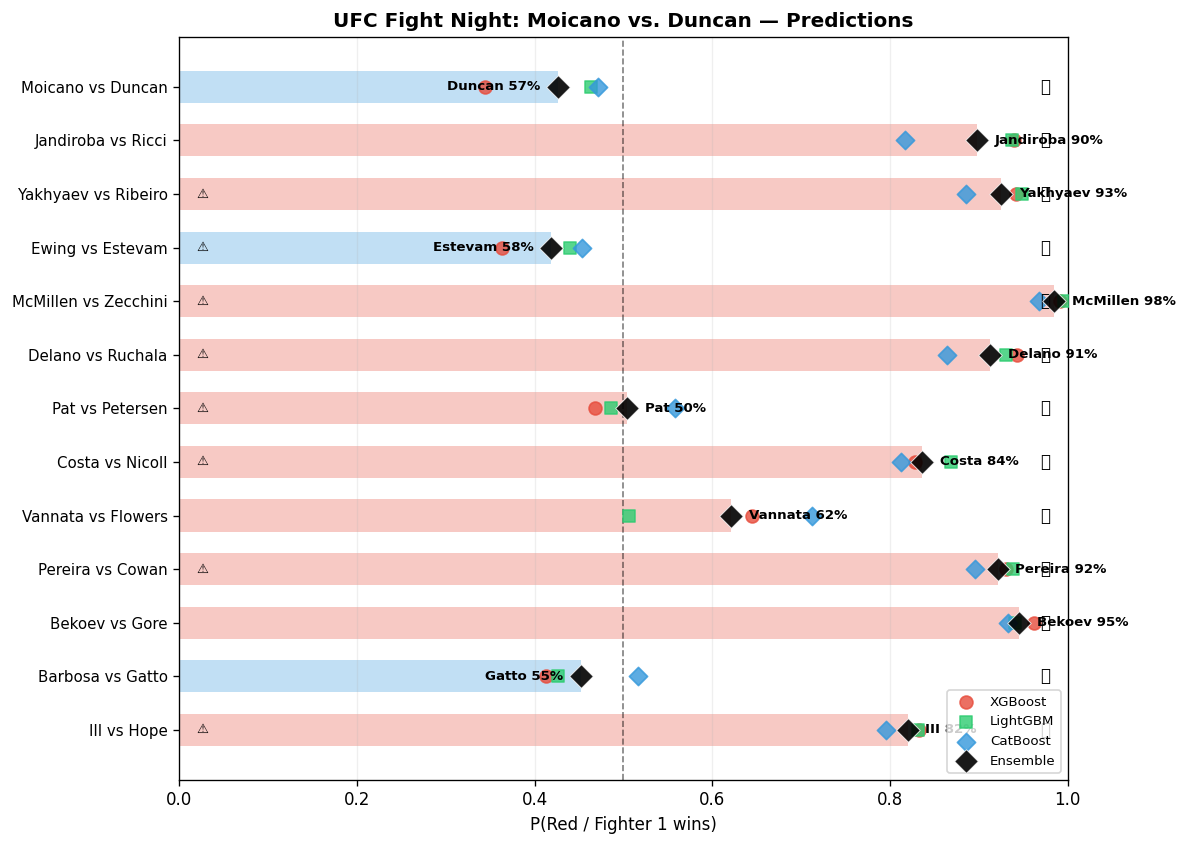

In [9]:
n_fights = len(results_df)
fig, ax = plt.subplots(figsize=(10, max(4, n_fights * 0.55)))

fight_labels = [f"{r['fighter_1'].split()[-1]} vs {r['fighter_2'].split()[-1]}"
                for _, r in results_df.iterrows()]
y_pos = range(n_fights)

ens_p = results_df['Ensemble_prob'].values
colors = ['#e74c3c' if p >= 0.5 else '#3498db' for p in ens_p]
ax.barh(y_pos, ens_p, color=colors, alpha=0.3, height=0.6, edgecolor='none')

markers = {'XGBoost': 'o', 'LightGBM': 's', 'CatBoost': 'D'}
dot_colors = {'XGBoost': '#e74c3c', 'LightGBM': '#2ecc71', 'CatBoost': '#3498db'}
for name in models:
    if f'{name}_prob' in results_df.columns:
        p = results_df[f'{name}_prob'].values
        ax.scatter(p, y_pos, marker=markers.get(name, 'o'), s=60, alpha=0.8,
                  color=dot_colors.get(name, 'gray'), label=name, zorder=3)

ax.scatter(ens_p, y_pos, marker='D', s=100, color='black', alpha=0.9,
          label='Ensemble', zorder=4, edgecolors='white', linewidths=0.5)

ax.axvline(0.5, color='black', ls='--', lw=1, alpha=0.5)

if has_results:
    for i, (_, row) in enumerate(results_df.iterrows()):
        if row['correct'] is True:
            ax.text(0.98, i, '✅', fontsize=10, va='center', ha='right',
                    transform=ax.get_yaxis_transform())
        elif row['correct'] is False:
            ax.text(0.98, i, '❌', fontsize=10, va='center', ha='right',
                    transform=ax.get_yaxis_transform())

for i, (_, row) in enumerate(results_df.iterrows()):
    if row.get('coverage') == 'profile_only':
        ax.text(0.02, i, '⚠️', fontsize=8, va='center', ha='left',
                transform=ax.get_yaxis_transform())

ax.set_yticks(list(y_pos))
ax.set_yticklabels(fight_labels, fontsize=9)
ax.set_xlabel('P(Red / Fighter 1 wins)')
ax.set_xlim(0, 1)
ax.set_title(f'{event_name} — Predictions', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

for i, p in enumerate(ens_p):
    pick = results_df.iloc[i]['pick'].split()[-1]
    conf = max(p, 1-p)
    x_pos = p + 0.02 if p >= 0.5 else p - 0.02
    ha = 'left' if p >= 0.5 else 'right'
    ax.text(x_pos, i, f"{pick} {conf:.0%}", va='center', ha=ha, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA / 'event_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Predictions

In [10]:
safe_name = re.sub(r'[^a-zA-Z0-9_]', '_', event_name.replace(' ', '_'))
out_file = DATA / f'predictions_{safe_name}.csv'

results_df.to_csv(out_file, index=False)
print(f"Saved: {out_file}")
print(f"Fights: {len(results_df)}")
if has_results:
    scored = results_df[results_df['correct'].notna()]
    if len(scored) > 0:
        print(f"Accuracy: {scored['correct'].sum()}/{len(scored)} ({scored['correct'].mean():.0%})")

Saved: data/predictions_UFC_Fight_Night__Moicano_vs__Duncan.csv
Fights: 13
Accuracy: 7/13 (54%)
